# A4-Q4: minGRU

In [50]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pylab as plt
from tqdm import tqdm
import oos_dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'


def red_text(t):
    return f'\033[31m{t}\033[0m'
print(device)
print(f'This is how you can make {red_text("text in red")}')

cuda
This is how you can make text in red


## Read in the data

In [51]:
# For development purposes, you might opt to test your code on a smaller subset
# of the text, like the first 5000 characters.
oos = oos_dataset.Origin(start=41, stop=10015+41, seq_length=15)

Character set: " .abcdefghijklmnopqrstuvwxy" (first char is a space)
There are 27 characters in our character set


In [52]:
# We'll use this DataLoader for minibatch SGD
dl = torch.utils.data.DataLoader(oos, batch_size=128, shuffle=True)

In [53]:
# Let's get a batch just to see what it looks like.
xb, tb = next(iter(dl))
print(xb.shape)

torch.Size([128, 15, 27])


# Q4 (a) Complete `minGRU`

In [54]:
class minGRU(nn.Module):
    '''
     net = minGRU(in_dim, hidden_dim, out_dim, outfcn=nn.LogSoftmax(dim=-1))

     Create a minGRU network.

     Inputs:
      in_dim      dimension of input
      hidden_dim  dimension of hidden layers
      out_dim     dimension of output
      outfcn      an instance of an activation function for output
                  (default: nn.LogSoftmax(dim=-1))

     Usage:
     > net = minGRU(27, 300, 27, outfcn=nn.Tanh())
     > x = torch.randn((3, 10, 27))  # batch of 3 sequences of length 10
     > y = net(x)
     Returns y with shape (3, 10, 27)
     
     > y = net.step(x[:,0,:].unsqueeze(1))
     Returns y with shape (3, 1, 27)
    '''
    def __init__(self, in_dim, hidden_dim, out_dim, outfcn=nn.LogSoftmax(dim=-1)):
        super().__init__()
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim

        self.h = None
        
        # Gate: g_t = sigmoid(x_t @ Ug + bg)
        self.gate = nn.Linear(in_dim, hidden_dim)
        self.gate_act = nn.Sigmoid()

        # Candidate hidden: h_tilde = x_t @ U + b
        self.candidate = nn.Linear(in_dim, hidden_dim)

        # Output: y_t = phi(h_t @ V + by)
        self.output = nn.Linear(hidden_dim, out_dim)
        self.outfcn = outfcn

        self.losses = []
        self.to(device)
    

    def reset(self):
        self.h = None


    def step(self, x):
        '''
        y = net.step(x)

        Performs one time step of an entire batch, using the input x and the
        saved hidden state (net.h) to generate the output y.
        
        Input:
         x  (batch_size, 1, in_dim) tensor

        Output:
         y  (batch_size, 1, out_dim) tensor
        '''
        _, T, _ = x.shape
        assert T == 1, 'minGRU.step: x must have shape (batch_size, 1, in_dim)'
        if self.h is None:
            self.h = torch.zeros((x.shape[0], 1, self.hidden_dim)).to(device)

        # g_t = sigmoid(x_t @ Ug + bg)
        g = self.gate_act(self.gate(x))
        # h_tilde_t = x_t @ U + b
        h_tilde = self.candidate(x)
        # h_t = g_t * h_tilde_t + (1 - g_t) * h_{t-1}
        self.h = g * h_tilde + (1 - g) * self.h
        # y_t = phi(h_t @ V + by)
        y = self.outfcn(self.output(self.h))

        return y
        

    def forward(self, x_batch):
        '''
        y = net.forward(x_batch) or y = net(x_batch)

        Performs a forward pass of an entire batch of sequences, using the input x_batch to
        generate the output y.
        The hidden state, h, is carried forward through timesteps but not returned.

        Input:
         x_batch  (batch_size, T, in_dim) tensor containing a batch of
                  sequences of T tokens.

        Output:
         y        (batch_size, T, out_dim) tensor
        '''
        samples, T, in_dim = x_batch.shape
        assert in_dim == self.in_dim, 'minGRU.forward: x_batch must have shape (batch_size, T, in_dim)'

        x_batch = x_batch.to(device)
        self.reset()
        
        outputs = []
        for t in range(T):
            xt = x_batch[:, t:t+1, :]   # (batch, 1, in_dim)
            yt = self.step(xt)           # (batch, 1, out_dim)
            outputs.append(yt)

        y = torch.cat(outputs, dim=1)    # (batch, T, out_dim)
        return y


In [55]:
# Take your mniGRU implementation for a quick spin!
net = minGRU(27, 300, 27, nn.Tanh())
y = net(xb)
print(y.shape)
print(net.h)

torch.Size([128, 15, 27])
tensor([[[-0.0835, -0.1136, -0.1341,  ...,  0.0695, -0.0184,  0.1293]],

        [[-0.1400, -0.2628, -0.0773,  ...,  0.1137, -0.0919,  0.1585]],

        [[-0.0035, -0.1844, -0.0464,  ...,  0.0891, -0.0491,  0.1962]],

        ...,

        [[-0.1508, -0.1551, -0.1029,  ...,  0.1394, -0.0558,  0.0649]],

        [[-0.0268, -0.3298, -0.1181,  ...,  0.1841, -0.0686,  0.2118]],

        [[-0.0665, -0.2169, -0.1339,  ...,  0.1839, -0.0705, -0.0345]]],
       device='cuda:0', grad_fn=<AddBackward0>)


# Q4 (b) Complete `DeepminGRU`

In [56]:
class DeepminGRU(nn.Module):
    '''
    net = DeepminGRU(n_layers, in_dim, hidden_dim)

    Creates a deep minGRU network with n_layers layers, where the input
    to each minGRU layer has dimension in_dim, and the hidden layer has
    dimension hidden_dim.

    The output of the last (top) layer should use a LogSoftmax activation
    function.

    Usage:
    > net = DeepminGRU(3, 27, 300)
    > x = torch.randn((3, 10, 27))  # batch of 3 sequences of length 10
    > y = net(x)
    Returns y with shape (3, 10, 27)

    > y = net.step(x[:,0,:].unsqueeze(1))
    Returns y with shape (3, 1, 27), where y[n,0,:] is the log of a probability vector
    '''
    def __init__(self, n_layers, in_dim, hidden_dim):
        super().__init__()
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.losses = []

        # Stack of minGRU layers.
        # All layers have in_dim input and hidden_dim output.
        # Only the top (last) layer uses LogSoftmax; intermediate layers use Tanh.
        layer_list = []
        for i in range(n_layers):
            if i < n_layers - 1:
                layer_list.append(minGRU(in_dim, hidden_dim, in_dim, outfcn=nn.Tanh()))
            else:
                layer_list.append(minGRU(in_dim, hidden_dim, in_dim, outfcn=nn.LogSoftmax(dim=-1)))
        self.layers = nn.ModuleList(layer_list)

        self.to(device)


    def reset(self):
        for l in self.layers:
            l.reset()
            

    def step(self, x):
        # Pass a single time-step token through every layer in sequence
        out = x.to(device)
        for layer in self.layers:
            out = layer.step(out)
        return out
    

    def forward(self, x):
        # Pass a full sequence through every layer in sequence
        out = x.to(device)
        for layer in self.layers:
            out = layer(out)
        return out
                
    def predict(self, x, n=10):
        '''
        y = net.predict(x, n=10)

        Given a sequence of one-hot vectors x, predict the next n
        outputs.

        Inputs:
         x  (1, T, in_dim) tensor, where T is the length of the sequence
         n  int, the number of outputs to predict

        Outputs:
         y  (1, n, out_dim) tensor of probability vectors
        '''
        with torch.no_grad():
            assert x.shape[0] == 1, 'predict: x must have shape (1, T, in_dim)'
            assert x.shape[2] == self.in_dim, 'predict: x must have shape (1, T, in_dim)'
            output = torch.zeros((1, n, self.in_dim)).to(device)
            self.reset()

            # Feed the prompt through the network to build up hidden states
            x = x.to(device)
            last_out = self.step(x[:, 0:1, :])
            for t in range(1, x.shape[1]):
                last_out = self.step(x[:, t:t+1, :])

            # Now autoregressively predict n characters.
            # last_out is log-softmax; take argmax, convert to one-hot, feed back in.
            for k in range(n):
                # Pick most likely character
                idx = last_out[0, 0, :].argmax()
                # Build one-hot vector
                one_hot = torch.zeros((1, 1, self.in_dim)).to(device)
                one_hot[0, 0, idx] = 1.0
                output[0, k, :] = one_hot[0, 0, :]
                # Step forward
                last_out = self.step(one_hot)

        return output
    
    def bptt(self, dl, epochs=10, lr=0.001):
        '''
        net.bptt(dl, epochs=10, lr=0.001)
        Perform backprop-through-time (BPTT) to learn from the sequences in the dataset.
         dl      Dataloader object (see above)
         epochs  How many epochs to train for
         lr      Learning rate
        '''
        loss_fcn = nn.NLLLoss()
        optim = torch.optim.Adam(self.parameters(), lr=lr)
        for epoch in tqdm(range(epochs)):
            total_loss = 0.
            for x, t in dl:
                x, t = x.to(device), t.to(device)
                y = self(x)
                loss = torch.tensor(0., device=device, requires_grad=True)
                for k in range(t.shape[1]):
                    ys = y[:,k,:].squeeze()
                    ts = t[:,k]
                    loss = loss + loss_fcn(ys, ts)
                optim.zero_grad()
                loss.backward()
                optim.step()
                total_loss += loss.detach().cpu().item() * len(t)
            self.losses.append(total_loss/len(dl.dataset))
        plt.plot(self.losses)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss')


# Q4 (c) Create and Train a Network

In [57]:
# Create a 3-layer deep minGRU with hidden size 300
net = DeepminGRU(n_layers=3, in_dim=27, hidden_dim=300)
print(net)


DeepminGRU(
  (layers): ModuleList(
    (0-1): 2 x minGRU(
      (gate): Linear(in_features=27, out_features=300, bias=True)
      (gate_act): Sigmoid()
      (candidate): Linear(in_features=27, out_features=300, bias=True)
      (output): Linear(in_features=300, out_features=27, bias=True)
      (outfcn): Tanh()
    )
    (2): minGRU(
      (gate): Linear(in_features=27, out_features=300, bias=True)
      (gate_act): Sigmoid()
      (candidate): Linear(in_features=27, out_features=300, bias=True)
      (output): Linear(in_features=300, out_features=27, bias=True)
      (outfcn): LogSoftmax(dim=-1)
    )
  )
)


In [58]:
# This is how you would call your network.
x, t = next(iter(dl))
y = net(x)

100%|██████████| 200/200 [11:33<00:00,  3.47s/it]


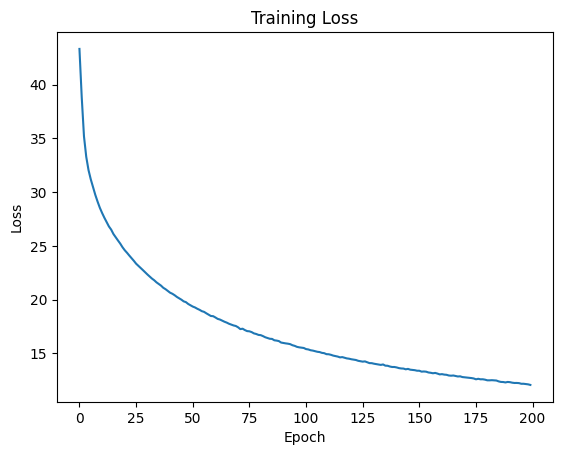

In [59]:
# Train for 50 epochs (run this cell multiple times to keep training)
net.bptt(dl, epochs=200, lr=0.001)


In [60]:
# You can save and re-load your model if you choose.
#torch.save(net.cpu(), 'origin.pt')
#net = torch.load('origin.pt').to(device)

# Q4 (d) Next-Letter Prediction Accuracy

In [65]:
# Evaluate next-letter prediction accuracy across all 9999 sequences
correct = 0
total = 0

net_eval = net  # use trained network
net_eval.eval()

with torch.no_grad():
    for x, t in torch.utils.data.DataLoader(oos, batch_size=256, shuffle=False):
        y = net_eval(x)                        # (batch, T, 27)
        last_pred = y[:, -1, :].argmax(dim=-1) # predicted next char index
        last_target = t[:, -1]                 # true next char index
        correct += (last_pred.cpu() == last_target.cpu()).sum().item()
        total += len(last_target)

accuracy = correct / total
print(f'Next-letter prediction accuracy: {correct}/{total} = {accuracy:.4f} ({accuracy*100:.1f}%)')


Next-letter prediction accuracy: 8582/9999 = 0.8583 (85.8%)


# Q4 (e) Predict the next 160 characters

In [64]:
# Choose a sequence randomly
v, t = oos.__getitem__(np.random.randint(len(oos)))

# Or enter your own prompt (don't be rude)
#v = oos.seq_i2v([oos.char_indices[cc] for cc in 'higher forms'])

# Use v.unsqueeze(0) to make it a batch with one sequence
prompt = v.unsqueeze(0)  # (1, T, 27)

# Predict the next 160 characters
pred_onehot = net.predict(prompt, n=160)          # (1, 160, 27)
pred_text = oos.seq_v2c(pred_onehot.squeeze(0))   # convert to string

# Print it out, with predicted text in red.
print(f'{oos.seq_v2c(v.squeeze())}{red_text(pred_text[:70])}')
print(f'{red_text(pred_text[70:])}')


ght to feel surpecies are that much remaining on the structure of the mutual relation
s of the makes due but it is publish hope in or in one very publishing my convinced that s
